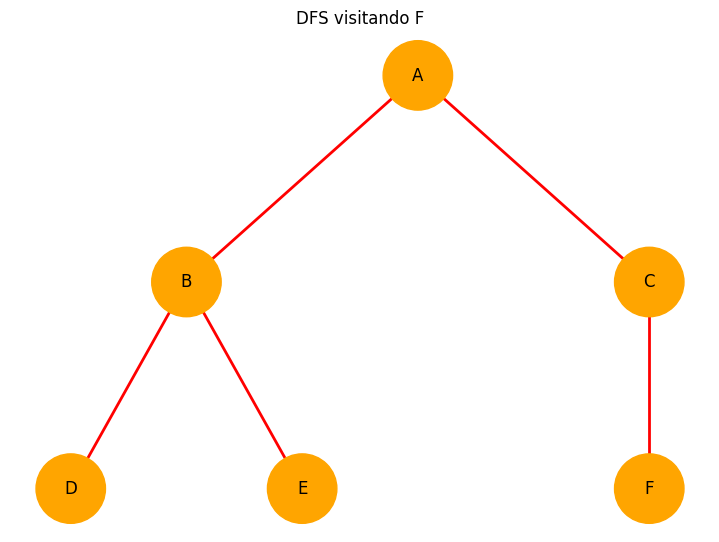


EXPLICACIÓN DFS
DFS (Depth First Search) recorre el grafo explorando lo más profundo posible.
Empieza en el nodo inicial y sigue un camino hasta que no haya más nodos.
Cuando llega a un nodo sin hijos, retrocede para explorar otro camino.
Por eso el recorrido fue:
A → B → D → E → C → F


In [17]:
!pip install networkx matplotlib pandas

import networkx as nx
import matplotlib.pyplot as plt
import time
from collections import deque
from IPython.display import clear_output
import pandas as pd

# -------- Crear grafo --------
G = nx.Graph()

edges = [
('A','B'),
('A','C'),
('B','D'),
('B','E'),
('C','F')
]

G.add_edges_from(edges)

# Posiciones para que parezca árbol
pos = {
'A':(0,3),
'B':(-1,2),'C':(1,2),
'D':(-1.5,1),'E':(-0.5,1),'F':(1,1)
}

# -------- Animación --------
def animate(nodes,edges,title):

    for i in range(len(nodes)):

        clear_output(wait=True)

        node_colors=[]
        for n in G.nodes():
            if n in nodes[:i+1]:
                node_colors.append("orange")
            else:
                node_colors.append("lightgray")

        edge_colors=[]
        for e in G.edges():
            if e in edges[:i]:
                edge_colors.append("red")
            else:
                edge_colors.append("black")

        plt.figure(figsize=(7,5))

        nx.draw(
            G,pos,
            with_labels=True,
            node_color=node_colors,
            edge_color=edge_colors,
            node_size=2500,
            width=2
        )

        plt.title(title + " visitando " + nodes[i])
        plt.show()

        time.sleep(1)

# -------- BFS --------
def bfs(graph,start):

    visited=[]
    queue=deque([start])
    parent={start:None}
    edges=[]
    max_memory=1

    while queue:

        max_memory=max(max_memory,len(queue))

        node=queue.popleft()

        if node not in visited:

            visited.append(node)

            if parent[node]!=None:
                edges.append((parent[node],node))

            for n in graph.neighbors(node):
                if n not in parent:
                    parent[n]=node
                    queue.append(n)

    return visited,edges,max_memory

# -------- DFS --------
def dfs(graph,start):

    visited=[]
    stack=[start]
    parent={start:None}
    edges=[]
    max_memory=1

    while stack:

        max_memory=max(max_memory,len(stack))

        node=stack.pop()

        if node not in visited:

            visited.append(node)

            if parent[node]!=None:
                edges.append((parent[node],node))

            for n in reversed(list(graph.neighbors(node))):
                if n not in parent:
                    parent[n]=node
                    stack.append(n)

    return visited,edges,max_memory


# -------- Ejecutar BFS --------
bfs_nodes,bfs_edges,bfs_mem=bfs(G,'A')

print("Recorrido BFS inicia en 5 segundos:")
print(" → ".join(bfs_nodes))

time.sleep(5)

animate(bfs_nodes,bfs_edges,"BFS")

import time

time.sleep(5)

print("\nEXPLICACIÓN BFS")
print("BFS (Breadth First Search) recorre el grafo por niveles.")
print("Primero visita el nodo inicial A.")
print("Luego visita todos los nodos vecinos del mismo nivel.")
print("Después continúa con los nodos del siguiente nivel.")
print("Por eso el recorrido fue:")
print(" → ".join(bfs_nodes))

time.sleep(6)

# -------- Ejecutar DFS --------
dfs_nodes,dfs_edges,dfs_mem=dfs(G,'A')

print("Recorrido DFS inicia en 5 segundos:")
print(" → ".join(dfs_nodes))

time.sleep(5)

animate(dfs_nodes,dfs_edges,"DFS")
time.sleep(5)

print("\nEXPLICACIÓN DFS")
print("DFS (Depth First Search) recorre el grafo explorando lo más profundo posible.")
print("Empieza en el nodo inicial y sigue un camino hasta que no haya más nodos.")
print("Cuando llega a un nodo sin hijos, retrocede para explorar otro camino.")
print("Por eso el recorrido fue:")
print(" → ".join(dfs_nodes))

time.sleep(6)
